# 🤖 Build Your Own AI Agent
**From zero to a working agent — in one session**


**Notebook developed by** SzuLun Huang <szuh@berkeley.edu>  
**Under the guidance of** Eric Van Dusen <ericvd@berkeley.edu>  
**UC Berkeley, Data Science**

---

### What is an Agent?

A plain LLM (like what you used in the earlier notebook) answers one question and stops.
An **agent** is different — it keeps going until it finishes a task:

```
Plain LLM:  You ask → It answers → Done

Agent:      You give a task
              → Model decides what to do
              → Calls a tool (search, write file, run code...)
              → Gets the result back
              → Decides what to do next
              → ... repeats until finished
```

Every agent — no matter how complex — is built from three things:

| Component | What it does |
|---|---|
| **Model** | The brain — reads the situation and decides the next action |
| **Tools** | The hands — functions that interact with the real world |
| **Loop** | The engine — keeps running until the task is done |

By the end of this notebook, you will have built all three from scratch.

---

### Roadmap
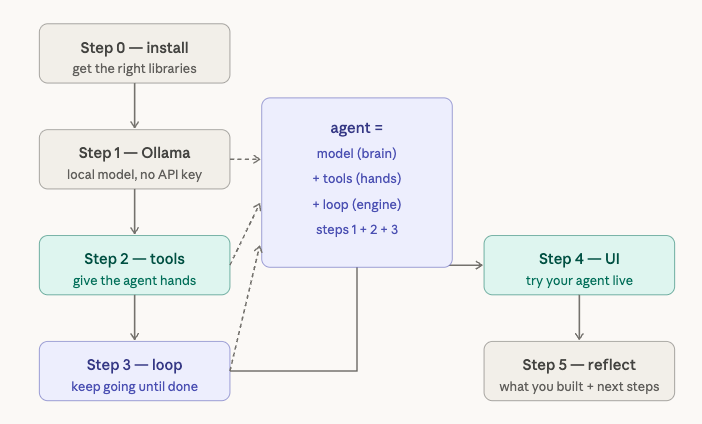


## Step 0 — Install dependencies

**What this does:** installs two extra packages on top of what is already on this JupyterHub.

| Package | Purpose |
|---|---|
| `duckduckgo-search` | Free web search — no API key required |
| `ipywidgets` | Interactive UI elements (buttons, sliders, text boxes) |

> `llama-cpp-python` is already installed on this JupyterHub — no need to reinstall it.

In [22]:
# ── Install extra packages needed for the agent ───────────────────────
!pip install duckduckgo-search ipywidgets --quiet
!pip install ddgs ipywidgets --quiet

print('✅ Done')

/srv/conda/envs/notebook/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=3006) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()
/srv/conda/envs/notebook/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=3006) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


✅ Done


## Step 1 — Load the model

**What this does:** loads the same Llama model you used in the earlier notebook.
Same path, same library, same parameters — nothing new here.

In [23]:
# ── Import all libraries we will use throughout this notebook ─────────
import json, os, re, subprocess, threading, time
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from ddgs import DDGS

from llama_cpp import Llama

print('✅ Imports ready')

✅ Imports ready


In [3]:
# ── Load the Llama model — same config as the earlier notebook ────────
MODEL_PATH = '/home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf'
N_CTX      = 4096
N_THREADS  = 4

print(f'Loading: {MODEL_PATH}')
print('This may take ~10 seconds...')

llm = Llama(
    model_path=MODEL_PATH,
    n_ctx=N_CTX,
    n_threads=N_THREADS,
    verbose=False
)
print('✅ Model ready')

Loading: /home/jovyan/shared/Llama-3.2-1B-Instruct-Q4_K_M.gguf
This may take ~10 seconds...


llama_context: n_ctx_per_seq (4096) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


✅ Model ready


⬇ Run this cell to confirm the model loaded correctly.
> If you see a response, you are ready to continue.
>
> 
> If you see an error, go back to Step 1 and check the model path.

In [16]:
# ── Sanity check — ask the model one simple question to confirm it loaded correctly
resp = llm.create_chat_completion(
    messages=[{'role': 'user', 'content': 'Say hello in one sentence.'}],
    max_tokens=50
)
print(resp['choices'][0]['message']['content'])

Hello, it's nice to meet you.


## Step 2 — Define Tools

**The problem:** a model on its own can only produce text. It cannot search the web, save a file, or run code. It is stuck inside its training data.

**Our solution:** give the model tools — Python functions it can call to interact with the real world.

We define 4 tools:

| Tool | What it does | Safety consideration |
|---|---|---|
| `search_web` | DuckDuckGo search (free, no key) | Low risk |
| `read_file` | Read a file from the workspace | Locked to `~/agent_workspace/` |
| `write_file` | Write a file to the workspace | Locked to `~/agent_workspace/` |
| `run_shell` | Execute a shell command | Requires human approval |

**Why the safety restrictions?**
Without them, an agent could accidentally overwrite system files or run destructive commands. Two rules applied here:
1. `write_file` uses `os.path.basename()` to strip any `../` path traversal — the agent can never escape the workspace folder
2. `run_shell` implements **Human-in-the-Loop (HITL)**: the agent must ask you before executing any shell command

In [18]:
# ── Create a safe workspace folder where the agent can read/write files
WORKSPACE  = os.path.expanduser('~/agent_workspace')
HITL_SHELL = True  # set False to skip shell confirmation

os.makedirs(WORKSPACE, exist_ok=True)
print(f'Workspace: {WORKSPACE}')

Workspace: /home/jovyan/agent_workspace


In [19]:
# ── Tool 1-3: search and file tools (low risk) ────────────────────────
def search_web(query: str, max_results: int = 3) -> str:
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=max_results))
        if not results:
            return 'No results found.'
        return '\n\n'.join(
            f"Title: {r['title']}\nURL: {r['href']}\nSummary: {r['body']}"
            for r in results
        )
    except Exception as e:
        return f'Search error: {e}'


def read_file(filename: str) -> str:
    try:
        with open(os.path.join(WORKSPACE, os.path.basename(filename))) as f:
            return f.read()
    except Exception as e:
        return f'Read error: {e}'


def write_file(filename: str, content: str) -> str:
    safe = os.path.join(WORKSPACE, os.path.basename(filename))
    try:
        with open(safe, 'w') as f:
            f.write(content)
        return f'Written: {safe}'
    except Exception as e:
        return f'Write error: {e}'


print('✅ search_web, read_file, write_file ready')

✅ search_web, read_file, write_file ready


In [20]:
# ── Tool 4: run_shell — dangerous, requires human approval (HITL) ─────
def run_shell(command: str) -> str:
    if HITL_SHELL:
        print(f'\n⚠️  Agent wants to run: {command}')
        if input('Allow? (yes/no): ').strip().lower() != 'yes':
            return 'Command blocked by user.'
    try:
        r = subprocess.run(command, shell=True, capture_output=True, text=True, timeout=30)
        return r.stdout.strip() or r.stderr.strip() or '(no output)'
    except Exception as e:
        return f'Shell error: {e}'


# ── Register all tools in one dict — the agent will look up tools here ─
TOOLS = {
    'search_web': search_web,
    'read_file' : read_file,
    'write_file': write_file,
    'run_shell' : run_shell,
}
print('✅ All tools registered:', list(TOOLS.keys()))

✅ All tools registered: ['search_web', 'read_file', 'write_file', 'run_shell']


In [26]:
# ── Quick test — verify each tool works before connecting to the agent ─
print('search_web:', search_web('Llama AI model', max_results=1))
print('write_file:', write_file('test.txt', 'hello agent'))
print('read_file :', read_file('test.txt'))
# run_shell is not tested here — it requires manual yes/no input
print('\n✅ All tools working')

search_web: Title: Llama (language model) - Wikipedia
URL: https://en.wikipedia.org/wiki/Llama_(language_model)
Summary: 2 weeks ago -Llama ("Large Language Model Meta AI" serving as a backronym) isa family of large language models (LLMs) released by Meta AI starting in February 2023. Llama models come in different sizes, ranging from 1 billion to 2 trillion parameters. Initially only a foundation model, starting with Llama ...
write_file: Written: /home/jovyan/agent_workspace/test.txt
read_file : hello agent

✅ All tools working


> **Key insight:** tools are just normal Python functions. The agent does not call them directly — it tells us *which* tool it wants to call and *with what arguments*, and our loop executes them. The model never has direct access to your filesystem or shell.

## Step 3 — The Agent Loop

**The problem:** a model that can only respond once is not an agent. We need it to keep working — searching, writing, deciding — until the task is truly done.

**Our solution:** a loop that:
1. Shows the model the current situation (task + everything that happened so far)
2. Asks it to decide what to do next
3. Executes that action
4. Adds the result to the situation
5. Repeats until the model says `done`

**How does the model communicate its decisions?**

We use a simple JSON protocol. The model must always respond with one of these:

```json
// To use a tool:
{"thought": "I need to search for recent news", "tool": "search_web", "args": {"query": "AI news 2025"}}

// To finish:
{"thought": "I have all the information", "tool": "done", "answer": "Here is the summary..."}
```

**One practical problem:** small models like Llama-3.2-1B do not always output clean JSON — they sometimes add commentary around it, or wrap it in markdown code blocks. We solve this with `parse_json_robust`, which tries three strategies before giving up:
1. Direct `json.loads()` parse
2. Regex to extract the largest `{}` block
3. Fallback: treat the whole response as a plain text answer

### The system prompt — giving the model its instructions

This is the "instruction manual" we give the model before the loop starts.
It tells the model three things:
- what tools it has access to
- exactly what format to respond in (JSON only)
- two examples showing what a correct response looks like

Without this, the model would reply in natural language and our loop would have no way to parse its intent.

In [28]:
# ── System prompt: tells the model how to behave as an agent ──────────
SYSTEM_PROMPT = """
You are an autonomous AI agent. Respond ONLY with a JSON object — no other text.

Available tools:
- search_web(query, max_results=3)
- read_file(filename)
- write_file(filename, content)
- run_shell(command)

To use a tool:   {"thought": "<1-2 sentences>", "tool": "<name>", "args": {<args>}}
When finished:   {"thought": "<1-2 sentences>", "tool": "done", "answer": "<answer>"}

Rules: never invent tool arguments. Max 10 steps.

Examples:
User: What is the capital of France?
Agent: {"thought": "I know this.", "tool": "done", "answer": "Paris."}

User: Search for Python 3.13 release date.
Agent: {"thought": "I need to search.", "tool": "search_web", "args": {"query": "Python 3.13 release date"}}
Tool result: Python 3.13 released October 2024...
Agent: {"thought": "Found it.", "tool": "done", "answer": "Python 3.13 was released in October 2024."}
"""

### Handling messy model output

We told the model to respond in JSON — but small models like Llama-3.2-1B do not always follow instructions perfectly. Sometimes they add commentary, sometimes they wrap the JSON in markdown code blocks.

`parse_json_robust` tries three strategies to extract the JSON no matter what the model outputs:
1. Direct parse — works if the output is clean JSON
2. Regex — finds the largest `{}` block inside the text
3. Fallback — if nothing works, treat the whole response as a plain text answer

In [29]:
# ── Robust JSON parser — handles messy model output gracefully ────────
def parse_json_robust(text: str) -> dict:
    # Strategy 1: direct parse
    try:
        return json.loads(text.strip())
    except json.JSONDecodeError:
        pass
    # Strategy 2: regex — find largest {} block
    for m in sorted(re.findall(r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', text, re.DOTALL), key=len, reverse=True):
        try:
            return json.loads(m)
        except json.JSONDecodeError:
            continue
    # Strategy 3: fallback — treat as plain answer
    return {'thought': 'Could not parse JSON', 'tool': 'done', 'answer': text.strip()}

### The agent loop — putting it all together

This is the core of the agent. It connects everything we built in Steps 1 and 2:
```
task
  → model decides (create_chat_completion)
  → parse decision (parse_json_robust)
  → execute tool (TOOLS dict)
  → add result to messages  ← this is the agent's memory
  → repeat until tool == "done"
```

The key line is the last one before the loop repeats:
```python
messages.append({'role': 'user', 'content': f'Tool result: {result}\n\nContinue.'})
```
This is what gives the agent memory — every tool result gets added back into the conversation, so the model always knows what happened in previous steps.

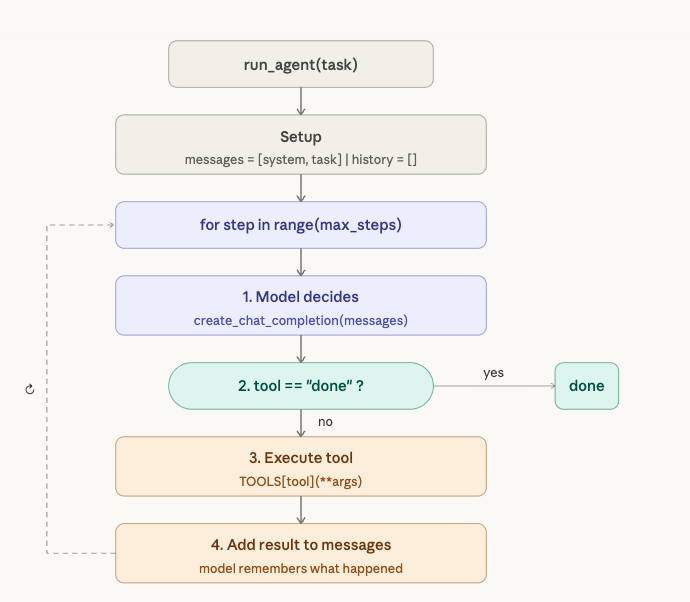

In [32]:
# ── The agent loop: decide → act → observe → repeat until done ────────
def run_agent(task: str, max_steps: int = 10, verbose: bool = True) -> tuple:
    """Run the agent loop. Returns (final_answer, history)."""
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': f'Task: {task}'}
    ]
    history = []

    for step in range(1, max_steps + 1):
        if verbose:
            print(f'\n--- Step {step}/{max_steps} ---')

        # 1. Model decides what to do next
        response = llm.create_chat_completion(
            messages=messages,
            max_tokens=200,
            temperature=0.7
        )
        raw      = response['choices'][0]['message']['content']
        decision = parse_json_robust(raw)

        thought = decision.get('thought', '')
        tool    = decision.get('tool', 'done')
        args    = decision.get('args', {})

        if verbose:
            print(f'Thought: {thought}')
            print(f'Tool   : {tool}', f'| Args: {args}' if args else '')

        # 2. If done, return the answer
        if tool == 'done':
            answer = decision.get('answer', '(no answer)')
            history.append({'step': step, 'thought': thought, 'tool': 'done', 'args': {}, 'result': answer})
            if verbose:
                print(f'\n✅ Done in {step} steps\nAnswer: {answer}')
            return answer, history

        # 3. Execute the tool
        if tool not in TOOLS:
            result = f'Unknown tool: {tool}. Available: {list(TOOLS.keys())}'
        else:
            try:
                result = TOOLS[tool](**args)
            except TypeError as e:
                result = f'Tool argument error: {e}'

        if verbose:
            print(f'Result : {str(result)[:300]}')

        # 4. Add result to memory so model remembers what happened
        history.append({'step': step, 'thought': thought, 'tool': tool, 'args': args, 'result': result})
        messages.append({'role': 'assistant', 'content': raw})
        messages.append({'role': 'user', 'content': f'Tool result: {result}\n\nContinue.'})

    return 'Max steps reached.', history


print('✅ Agent loop ready')

✅ Agent loop ready


In [34]:
# ── Test 1: simple reasoning — no tools needed ────────────────────────
answer, history = run_agent('What is the capital of Japan?')


--- Step 1/10 ---
Thought: I know this.
Tool   : done 

✅ Done in 1 steps
Answer: Tokyo.


In [36]:
# Test 2 — search once and stop
answer, history = run_agent(
    'Search for what year the Moon was first landed on. '
    'Once you find the year, call done immediately.'
)


--- Step 1/10 ---
Thought: I need to search the web for the year the Moon was first landed on.
Tool   : search_web | Args: {'query': 'Moon first landed on year'}
Result : Title: Moonlanding- Wikipedia
URL: https://en.wikipedia.org/wiki/Moon_landing
Summary: AMoonlandingor lunarlandingis the arrival of a spacecraft on the surface of theMoon, including both crewed and robotic missions. Thefirsthuman-made object to touch theMoonwas Luna 2 in 1959.[3].

Title: How do we 

--- Step 2/10 ---
Thought: I found the year the Moon was first landed on.
Tool   : done 

✅ Done in 2 steps
Answer: 1969


### Inspecting the agent trace

Run this cell whenever the agent gives an unexpected result.
It shows you exactly what the model was thinking at each step —
which tool it chose, what arguments it passed, and what came back.

In [13]:
# ── Inspect history — use this to debug when the agent does something unexpected
print('=== AGENT HISTORY ===')
for h in history:
    print(f"\nStep {h['step']} [{h['tool']}]")
    print(f"  Thought: {h['thought']}")
    if h['args']:
        print(f"  Args   : {h['args']}")
    print(f"  Result : {str(h['result'])[:200]}")

=== AGENT HISTORY ===

Step 1 [search_web]
  Thought: I'm searching for facts about the James Webb telescope.
  Args   : {'query': 'James Webb telescope facts'}
  Result : No results found.

Step 2 [search_web]
  Thought: No results found. Let's try again.
  Args   : {'query': 'James Webb telescope facts'}
  Result : No results found.

Step 3 [search_web]
  Thought: The James Webb Space Telescope is not yet operational. Let's try a different search.
  Args   : {'query': 'James Webb Space Telescope launch date'}
  Result : No results found.

Step 4 [search_web]
  Thought: I need to try a different approach. Let's search for launch dates for the James Webb Space Telescope.
  Args   : {'query': 'James Webb Space Telescope launch date'}
  Result : Title: James McNamara | Creative Writing Forums - Writing Help, Writing ...
URL: https://www.writingforums.org/members/james-mcnamara.82301/
Summary: Apr 30, 2017 · James McNamara is a member of Creat

Step 5 [read_file]
  Thought: I've found som

> **Notice the `messages` list:** every tool result gets added back into the conversation. This is the agent's **state** — its memory of what has happened. Without it, the model would forget its previous steps and start over each time.

## Step 4 — Interactive UI

Wraps the agent in a widget so you can give it any task and watch it think step by step.

**Controls:**
- **Max steps slider** — how many actions the agent is allowed before it is forced to stop
- **HITL checkbox** — when checked, the agent must ask for your approval before running any shell command
- **Agent trace** — after the run, you can see exactly what the agent was thinking at each step

> **Note:** We are using Llama-3.2-1B, a very small model. It works best with
> simple, single-step tasks. Complex multi-step tasks may produce unexpected results —
> that is normal, and actually a good thing to observe.

**Tasks that work well with this model:**
```
What year was the Eiffel Tower built?
Search for one fact about Mars.
What is the capital of Brazil?
Write the word "hello" to a file called hello.txt
```

**Tasks that will likely fail (good for discussion):**
```
Search for AI news and save a summary to news.md
Write a Python script and then run it
```

In [49]:
# ── Build UI widgets and connect button handlers ──────────────────────
task_input_ag   = widgets.Textarea(
    placeholder='Give the agent a task...\nE.g. What year was the Moon first landed on?',
    layout={'width': '660px', 'height': '80px'}
)
steps_slider_ag = widgets.IntSlider(value=8, min=2, max=15, step=1,
                                     description='Max steps:', layout={'width': '400px'})
hitl_toggle_ag  = widgets.Checkbox(value=True,
                                    description='Require approval for shell commands (HITL)',
                                    indent=False)
run_btn_ag   = widgets.Button(description='Run Agent', button_style='primary',
                               layout={'width': '160px', 'height': '40px'})
clear_btn_ag = widgets.Button(description='Clear', button_style='warning',
                               layout={'width': '100px', 'height': '40px'})
output_ag    = widgets.Output()

display(HTML("""
<div style="font-family:'IBM Plex Mono','Fira Code',monospace;
            background:#ffffff;border:1px solid #3b5268;
            border-radius:12px;padding:18px 20px;margin:10px 0;color:#1a1a2e;width:680px">
  <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
              letter-spacing:0.15em;margin-bottom:8px">Agent Lab</div>
  <h3 style="color:#1a1a2e;margin:0 0 6px;font-size:1.0em">Your AI Agent — Llama 3.2 local</h3>
  <p style="color:#374151;font-size:0.82em;margin:0">
    Files go to <code>~/agent_workspace/</code>. Shell requires your approval.
  </p>
</div>
"""))
display(HTML('<div style="font-family:monospace;font-size:0.82em;font-weight:bold;margin:8px 0 2px">Task:</div>'))
display(task_input_ag)
display(steps_slider_ag)
display(hitl_toggle_ag)
display(HTML('<div style="margin:8px 0"></div>'))
display(widgets.HBox([run_btn_ag, clear_btn_ag]))
display(output_ag)

TOOL_COLORS = {
    'done'      : '#16a34a', 'search_web': '#1d6fa8',
    'write_file': '#7c3aed', 'read_file' : '#b45309',
    'run_shell' : '#dc2626',
}

def on_run_ag(b):
    global HITL_SHELL
    task = task_input_ag.value.strip()
    if not task:
        with output_ag:
            clear_output()
            display(HTML('<span style="color:#f87171;font-family:monospace">Please enter a task!</span>'))
        return

    HITL_SHELL = hitl_toggle_ag.value
    run_btn_ag.disabled    = True
    run_btn_ag.description = 'Running...'

    with output_ag:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono',monospace;background:#f9fafb;
                    border:1px solid #e5e7eb;border-radius:12px;
                    padding:16px 20px;margin-top:10px;width:640px">
          <div style="font-size:0.63em;color:#1d6fa8;text-transform:uppercase;
                      letter-spacing:0.15em;margin-bottom:8px">Running...</div>
          <div style="font-size:0.82em;color:#374151">Task: <em>{task}</em></div>
          <div style="margin-top:6px;font-size:0.78em;color:#6b7280">Model is thinking... (~20 sec per step)</div>
        </div>
        """))

    store = {}

    def run():
        ans, hist = run_agent(task, max_steps=steps_slider_ag.value, verbose=False)
        store['answer']  = ans
        store['history'] = hist

    t = threading.Thread(target=run)
    t.start()
    t.join()

    answer  = store.get('answer', '')
    history = store.get('history', [])

    trace_html = ''
    for h in history:
        color    = TOOL_COLORS.get(h['tool'], '#374151')
        preview  = str(h['result'])[:400] + ('...' if len(str(h['result'])) > 400 else '')
        args_str = json.dumps(h.get('args', {}), ensure_ascii=False) if h.get('args') else ''
        trace_html += f"""
        <div style="border-left:3px solid {color};padding:10px 14px;
                    margin-bottom:8px;background:#f9fafb;border-radius:0 6px 6px 0">
          <div style="font-size:0.72em;color:{color};font-weight:bold;margin-bottom:4px">
            Step {h['step']} — {h['tool']}
          </div>
          <div style="font-size:0.8em;color:#374151;margin-bottom:4px"><em>{h['thought']}</em></div>
          {'<div style="font-size:0.75em;color:#6b7280;margin-bottom:4px">Args: ' + args_str + '</div>' if args_str else ''}
          <div style="font-size:0.78em;color:#1a1a2e;background:#fff;
                      border:1px solid #e5e7eb;border-radius:4px;
                      padding:8px 10px;white-space:pre-wrap">{preview}</div>
        </div>
        """

    with output_ag:
        clear_output()
        display(HTML(f"""
        <div style="font-family:'IBM Plex Mono',monospace;width:660px">
          <div style="background:#fff;border:1px solid #e5e7eb;
                      border-radius:12px;padding:16px 20px;margin-bottom:12px">
            <div style="font-size:0.63em;color:#16a34a;text-transform:uppercase;
                        letter-spacing:0.15em;margin-bottom:8px">Done — {len(history)} steps</div>
            <div style="font-size:0.82em;color:#374151;margin-bottom:10px">Task: <em>{task}</em></div>
            <div style="background:#f0fdf4;border:1px solid #86efac;
                        border-radius:8px;padding:12px 14px;
                        font-size:0.82em;color:#1a1a2e;white-space:pre-wrap">{answer}</div>
          </div>
          <div style="font-size:0.72em;color:#6b7280;margin-bottom:8px;font-weight:bold">Agent trace:</div>
          {trace_html}
        </div>
        """))

    run_btn_ag.disabled    = False
    run_btn_ag.description = 'Run Agent'


def on_clear_ag(b):
    with output_ag:
        clear_output()
    task_input_ag.value = ''


run_btn_ag.on_click(on_run_ag)
clear_btn_ag.on_click(on_clear_ag)
print('✅ UI ready — enter a task above and click Run Agent')

Textarea(value='', layout=Layout(height='80px', width='660px'), placeholder='Give the agent a task...\nE.g. Wh…

IntSlider(value=8, description='Max steps:', layout=Layout(width='400px'), max=15, min=2)

Checkbox(value=True, description='Require approval for shell commands (HITL)', indent=False)

Output()

✅ UI ready — enter a task above and click Run Agent


> **Note:** If you see `(no answer)`, the model likely answered in the wrong JSON field.
> This is common with small models. Try a more specific task like:
> `What year was the Moon first landed on?`

## Step 5 — What you just built

### The anatomy of your agent

| Component | Where it lives in the code | What it does |
|---|---|---|
| **Model** | `llm.create_chat_completion()` | Reads the situation and decides the next action |
| **Tools** | `TOOLS` dict + 4 Python functions | Executes real-world actions (search, files, shell) |
| **State** | `messages` list growing with each step | The agent's memory of everything that has happened |
| **Loop** | `for step in range(1, max_steps + 1)` | Keeps the agent running until `done` |
| **Protocol** | JSON `{thought, tool, args}` | How model and loop communicate |

### How this compares to what you built earlier

| Earlier notebook | This agent |
|---|---|
| You send a prompt → model answers → done | You give a task → model keeps working until finished |
| Model can only produce text | Model can search, write files, run code |
| You control every step | Agent decides its own next step |
| One `create_chat_completion()` call | A loop of calls, each building on the last |

### The one-line definition

> **An agent is a model + tools + a loop. Everything else — memory, planning, multi-agent — is built on top of this.**

---

### Want to go deeper?

Open `agent_advanced.ipynb` for:
- **Failure analysis** — what goes wrong and why
- **Context compression** — preventing the agent from running out of memory on long tasks
- **Framework comparison** — how LangGraph, CrewAI, and OpenClaw build on exactly what you wrote here
- **Assignments** — four exercises to extend the agent yourself

In [51]:
# ── Agent Concepts Hangman Quiz ──────────────────────────────

QUESTION_POOL = [
    {
        "q": "What are the three core components of every agent?",
        "options": ["Model, Memory, Output", "Model, Tools, Loop", "Prompt, Response, History", "Input, Process, Output"],
        "answer": 1, "explanation": "Every agent needs a brain (Model), hands (Tools), and an engine (Loop) that keeps it running.", "part": "Step 3",
    },
    {
        "q": "What does `tool == 'done'` mean in the agent loop?",
        "options": ["The tool crashed", "The model wants to use a tool called done", "The task is complete — return the answer", "The loop has run out of steps"],
        "answer": 2, "explanation": "done is the exit condition. When the model says done, the loop stops and returns the answer.", "part": "Step 3",
    },
    {
        "q": "Why do we add the tool result back to `messages`?",
        "options": ["To make the response longer", "So the model remembers what happened in previous steps", "To avoid repeating the same tool", "Because the API requires it"],
        "answer": 1, "explanation": "Without adding results to messages, the model starts fresh every step and forgets what it already did.", "part": "Step 3",
    },
    {
        "q": "What is Human-in-the-Loop (HITL)?",
        "options": ["The model asking itself questions", "A human reviewing and approving certain agent actions", "Running the agent in a browser", "A type of memory system"],
        "answer": 1, "explanation": "HITL means a human stays in control of dangerous actions — you are the captain, the AI is the co-pilot.", "part": "Step 2",
    },
    {
        "q": "Why is `write_file` locked to `~/agent_workspace/`?",
        "options": ["To make files easier to find", "To prevent the agent from overwriting system files", "Because the model cannot handle full paths", "To save disk space"],
        "answer": 1, "explanation": "Without this restriction, the agent could accidentally overwrite system files or important data.", "part": "Step 2",
    },
    {
        "q": "What does `parse_json_robust` solve?",
        "options": ["It makes JSON files smaller", "It handles cases where the model adds extra text around the JSON", "It converts Python dicts to JSON", "It speeds up the agent loop"],
        "answer": 1, "explanation": "Small models do not always output clean JSON — they sometimes wrap it in markdown or add commentary.", "part": "Step 3",
    },
    {
        "q": "What is the agent's 'state' in our implementation?",
        "options": ["The HITL toggle value", "The messages list that grows with each step", "The tool result from the last step", "The system prompt"],
        "answer": 1, "explanation": "The messages list is the agent's short-term memory — everything that happened is stored there.", "part": "Step 3",
    },
    {
        "q": "What happens when `max_steps` is reached without a `done`?",
        "options": ["The agent starts over", "The kernel crashes", "The loop returns Max steps reached.", "The last tool result is returned as the answer"],
        "answer": 2, "explanation": "max_steps is a safety limit to prevent infinite loops. The loop exits gracefully with a message.", "part": "Step 3",
    },
    {
        "q": "Why does Llama-3.2-1B sometimes fail on complex tasks?",
        "options": ["It does not have access to the internet", "It is a small model with limited reasoning ability", "The tools are not compatible with it", "The context window is too small"],
        "answer": 1, "explanation": "1 billion parameters is very small. The model struggles to know when to stop or how to combine multiple tools.", "part": "Step 4",
    },
    {
        "q": "What is the difference between a plain LLM call and an agent?",
        "options": ["An agent is faster", "A plain LLM responds once and stops; an agent loops until the task is done", "An agent uses a different model", "There is no difference"],
        "answer": 1, "explanation": "The loop is what makes an agent an agent — it keeps working, using tools, until the task is complete.", "part": "Step 1",
    },
    {
        "q": "What does `TOOLS[tool](**args)` do?",
        "options": ["Looks up the tool name and calls it with the model's arguments", "Prints the tool name", "Adds the tool to the registry", "Validates the tool arguments"],
        "answer": 0, "explanation": "TOOLS is a dict mapping tool names to Python functions. **args unpacks the arguments the model provided.", "part": "Step 3",
    },
    {
        "q": "Which tool requires human approval before running?",
        "options": ["search_web", "write_file", "read_file", "run_shell"],
        "answer": 3, "explanation": "run_shell can execute any command on your machine — it is the most dangerous tool and requires your explicit approval.", "part": "Step 2",
    },
    {
        "q": "Why do we use `os.path.basename()` in `write_file`?",
        "options": ["To get the file extension", "To strip path traversal like ../../ so the agent cannot escape the workspace", "To convert relative paths to absolute paths", "To check if the file exists"],
        "answer": 1, "explanation": "Without basename(), the agent could pass a path like ../../etc/passwd and write outside the workspace.", "part": "Step 2",
    },
    {
        "q": "What does the system prompt tell the model in our agent?",
        "options": ["How fast to respond", "What tools it has and what JSON format to use", "How many steps it can take", "Which files it can access"],
        "answer": 1, "explanation": "The system prompt is the instruction manual — it tells the model about available tools and the exact JSON format to respond in.", "part": "Step 3",
    },
    {
        "q": "What is the purpose of few-shot examples in the system prompt?",
        "options": ["To make the prompt longer", "To show the model what a correct response looks like", "To list all available tools", "To set the temperature"],
        "answer": 1, "explanation": "Few-shot examples dramatically improve JSON compliance — especially for small models that need to see the format in action.", "part": "Step 3",
    },
]

NUM_QUESTIONS = 5
MAX_WRONG     = 6
pool_json     = json.dumps(QUESTION_POOL)

html = f"""
<style>
  .hm-wrap {{
    font-family: 'IBM Plex Mono', 'Fira Code', monospace;
    background: #f8fafc;
    border-radius: 14px;
    padding: 20px;
    max-width: 860px;
  }}
  .hm-header {{
    background: linear-gradient(135deg, #eff6ff, #dbeafe);
    border: 1px solid #bfdbfe;
    border-radius: 12px;
    padding: 16px 20px;
    margin-bottom: 16px;
    display: flex;
    justify-content: space-between;
    align-items: center;
  }}
  .hm-title {{ color: #1a1a2e; font-weight: 700; font-size: 1.05em; }}
  .hm-sub   {{ color: #475569; font-size: 0.72em; margin-top: 4px; }}

  .hm-body {{
    display: flex;
    gap: 20px;
    align-items: flex-start;
    margin-bottom: 16px;
  }}

  .hm-scaffold {{
    flex-shrink: 0;
    background: #ffffff;
    border: 1px solid #d1d5db;
    border-radius: 12px;
    padding: 12px;
    display: flex;
    flex-direction: column;
    align-items: center;
    gap: 8px;
    width: 160px;
  }}
  .hm-lives {{
    font-size: 0.72em;
    color: #475569;
    text-align: center;
  }}
  .hm-lives span {{ color: #f87171; font-weight: 700; }}

  .hm-qpanel {{ flex: 1; }}
  .hm-progress {{
    font-size: 0.72em;
    color: #475569;
    margin-bottom: 10px;
    display: flex;
    justify-content: space-between;
  }}
  .hm-progress .correct-count {{ color: #059669; font-weight: 700; }}
  .hm-progress .wrong-count   {{ color: #f87171; font-weight: 700; }}

  .q-block {{
    background: #ffffff;
    border: 1px solid #d1d5db;
    border-radius: 12px;
    padding: 16px 18px;
  }}
  .q-meta {{ display: flex; align-items: center; gap: 8px; margin-bottom: 10px; }}
  .q-part {{
    background: #bfdbfe; color: #0369a1; font-size: 0.62em; font-weight: 700;
    padding: 2px 9px; border-radius: 20px; text-transform: uppercase; letter-spacing: 0.05em;
  }}
  .q-num  {{ color: #475569; font-size: 0.68em; }}
  .q-text {{ color: #475569; font-size: 0.88em; font-weight: 600; line-height: 1.6; margin-bottom: 12px; }}

  .opt {{
    background: #f3f4f6; border: 1px solid #d1d5db; border-radius: 8px;
    padding: 11px 14px; margin-bottom: 7px; cursor: pointer;
    display: flex; align-items: flex-start; gap: 10px;
    transition: border-color 0.15s, background 0.15s;
  }}
  .opt:hover {{ border-color: #0369a1; background: #e0f2fe; }}
  .opt-letter {{
    background: #e5e7eb; color: #64748b; font-size: 0.70em; font-weight: 700;
    width: 20px; height: 20px; border-radius: 50%;
    display: flex; align-items: center; justify-content: center; flex-shrink: 0; margin-top: 1px;
  }}
  .opt-text {{ color: #64748b; font-size: 0.82em; line-height: 1.5; }}

  .opt.correct {{ background: #dcfce7; border-color: #059669; cursor: default; }}
  .opt.correct .opt-letter {{ background: #059669; color: #dcfce7; }}
  .opt.correct .opt-text   {{ color: #166534; }}
  .opt.wrong   {{ background: #fee2e2; border-color: #f87171; cursor: default; }}
  .opt.wrong .opt-letter   {{ background: #f87171; color: #fee2e2; }}
  .opt.wrong .opt-text     {{ color: #e53935; }}
  .opt.locked  {{ cursor: default; }}
  .opt.locked:hover        {{ border-color: #d1d5db; background: #f3f4f6; }}
  .opt.locked.correct:hover {{ border-color: #059669; background: #dcfce7; }}
  .opt.dim     {{ opacity: 0.35; cursor: default; pointer-events: none; }}

  .feedback {{
    margin-top: 8px; padding: 10px 14px; border-radius: 0 8px 8px 0;
    font-size: 0.78em; line-height: 1.6; color: #475569; display: none;
  }}
  .feedback.show       {{ display: block; }}
  .feedback.correct-fb {{ background: #05966910; border-left: 3px solid #059669; }}
  .feedback.wrong-fb   {{ background: #f8717110; border-left: 3px solid #f87171; }}

  .next-btn {{
    margin-top: 12px; padding: 8px 20px; border-radius: 8px;
    background: #bfdbfe; border: 1px solid #0369a1; color: #0369a1;
    font-family: inherit; font-size: 0.82em; font-weight: 700;
    cursor: pointer; display: none; transition: background 0.15s;
  }}
  .next-btn:hover {{ background: #e0f2fe; }}
  .next-btn.visible {{ display: inline-block; }}

  .final-screen {{
    background: #ffffff; border-radius: 12px; padding: 28px 24px;
    text-align: center; display: none;
  }}
  .final-screen.show {{ display: block; }}
  .final-big {{ font-size: 3.0em; font-weight: 700; line-height: 1; margin-bottom: 8px; }}
  .final-msg {{ font-size: 0.88em; margin-bottom: 16px; }}
  .retry-btn {{
    display: inline-block; padding: 10px 24px; border-radius: 8px;
    font-family: inherit; font-size: 0.85em; font-weight: 700;
    cursor: pointer; border: 1px solid; transition: opacity 0.15s;
  }}
  .retry-btn:hover {{ opacity: 0.75; }}

  .hm-svg line, .hm-svg circle, .hm-svg path {{
    stroke-linecap: round;
    transition: opacity 0.3s;
  }}
  .hm-stroke {{ opacity: 0; }}
  .hm-stroke.drawn {{ opacity: 1; }}
</style>

<div class="hm-wrap">

  <div class="hm-header">
    <div>
      <div style="font-size:0.58em;color:#0284c7;text-transform:uppercase;letter-spacing:0.15em;margin-bottom:3px">Step 6 — Final Quiz</div>
      <div class="hm-title">🪢 Agent Concepts Hangman</div>
      <div class="hm-sub">Wrong answer = one stroke. 6 strokes = game over. 🐔</div>
    </div>
    <div style="text-align:right;color:#475569;font-size:0.70em">
      <div>{NUM_QUESTIONS} questions</div>
      <div style="color:#0284c7;font-weight:700">{MAX_WRONG} lives</div>
    </div>
  </div>

  <div class="hm-body">

    <div class="hm-scaffold">
      <svg class="hm-svg" width="120" height="140" viewBox="0 0 120 140">
        <line x1="10" y1="135" x2="110" y2="135" stroke="#bfdbfe" stroke-width="3"/>
        <line x1="30"  y1="135" x2="30"  y2="10"  stroke="#bfdbfe" stroke-width="3"/>
        <line x1="30"  y1="10"  x2="75"  y2="10"  stroke="#bfdbfe" stroke-width="3"/>
        <line x1="75"  y1="10"  x2="75"  y2="28"  stroke="#bfdbfe" stroke-width="3"/>
        <circle class="hm-stroke" id="hm-s1" cx="75" cy="38" r="10" stroke="#f87171" stroke-width="2.5" fill="none"/>
        <line class="hm-stroke" id="hm-s2" x1="75" y1="48" x2="75" y2="90" stroke="#f87171" stroke-width="2.5"/>
        <line class="hm-stroke" id="hm-s3" x1="75" y1="60" x2="52" y2="78" stroke="#f87171" stroke-width="2.5"/>
        <line class="hm-stroke" id="hm-s4" x1="75" y1="60" x2="98" y2="78" stroke="#f87171" stroke-width="2.5"/>
        <line class="hm-stroke" id="hm-s5" x1="75" y1="90" x2="52" y2="115" stroke="#f87171" stroke-width="2.5"/>
        <line class="hm-stroke" id="hm-s6" x1="75" y1="90" x2="98" y2="115" stroke="#f87171" stroke-width="2.5"/>
      </svg>
      <div class="hm-lives">Lives left: <span id="lives-left">{MAX_WRONG}</span></div>
      <div id="wrong-pills" style="display:flex;flex-wrap:wrap;gap:3px;justify-content:center;margin-top:4px"></div>
    </div>

    <div class="hm-qpanel">
      <div class="hm-progress">
        <span>Question <span id="q-current">1</span> / {NUM_QUESTIONS}</span>
        <span><span class="correct-count" id="correct-count">0</span> correct &nbsp; <span class="wrong-count" id="wrong-count">0</span> wrong</span>
      </div>
      <div id="q-container"></div>
    </div>

  </div>

  <div class="final-screen" id="final-screen"></div>

</div>

<script>
(function() {{

  var POOL      = {pool_json};
  var N         = {NUM_QUESTIONS};
  var MAX_WRONG = {MAX_WRONG};

  var wrongCount   = 0;
  var correctCount = 0;
  var qIndex       = 0;
  var questions    = [];
  var gameOver     = false;

  var qContainer   = document.getElementById('q-container');
  var livesLeft    = document.getElementById('lives-left');
  var wrongPills   = document.getElementById('wrong-pills');
  var qCurrent     = document.getElementById('q-current');
  var correctEl    = document.getElementById('correct-count');
  var wrongEl      = document.getElementById('wrong-count');
  var finalScreen  = document.getElementById('final-screen');

  function shuffle(arr) {{
    var a = arr.slice();
    for (var i = a.length - 1; i > 0; i--) {{
      var j = Math.floor(Math.random() * (i + 1));
      var t = a[i]; a[i] = a[j]; a[j] = t;
    }}
    return a;
  }}

  function drawStroke(n) {{
    var el = document.getElementById('hm-s' + n);
    if (el) el.classList.add('drawn');
  }}

  function renderQuestion(qi) {{
    var q = questions[qi];
    qCurrent.textContent = qi + 1;

    var opts = '';
    q.options.forEach(function(opt, oi) {{
      opts +=
        '<div class="opt" id="opt-' + oi + '" onclick="hmAnswer(' + oi + ')">' +
          '<div class="opt-letter">' + String.fromCharCode(65 + oi) + '</div>' +
          '<div class="opt-text">' + opt + '</div>' +
        '</div>';
    }});

    qContainer.innerHTML =
      '<div class="q-block">' +
        '<div class="q-meta">' +
          '<span class="q-part">' + q.part + '</span>' +
          '<span class="q-num">Q' + (qi + 1) + '</span>' +
        '</div>' +
        '<div class="q-text">' + q.q + '</div>' +
        opts +
        '<div class="feedback" id="fb"></div>' +
        '<button class="next-btn" id="next-btn" onclick="hmNext()">Next question →</button>' +
      '</div>';
  }}

  window.hmAnswer = function(oi) {{
    if (gameOver) return;
    var q       = questions[qIndex];
    var correct = q.answer;
    var isRight = (oi === correct);
    var fb      = document.getElementById('fb');
    var nextBtn = document.getElementById('next-btn');

    for (var j = 0; j < q.options.length; j++) {{
      var el = document.getElementById('opt-' + j);
      if (!el) continue;
      el.classList.add('locked');
      el.removeAttribute('onclick');
      if (j === correct)       el.classList.add('correct');
      else if (j === oi)       el.classList.add('wrong');
      else                     el.classList.add('dim');
    }}

    if (isRight) {{
      correctCount++;
      correctEl.textContent = correctCount;
      fb.className  = 'feedback show correct-fb';
      fb.innerHTML  = '✅ <strong style="color:#059669">Correct!</strong> ' + q.explanation;
    }} else {{
      wrongCount++;
      wrongEl.textContent = wrongCount;
      drawStroke(wrongCount);
      livesLeft.textContent = MAX_WRONG - wrongCount;

      var pill = document.createElement('div');
      pill.style.cssText = 'background:#f8717120;border:1px solid #f87171;border-radius:4px;padding:1px 6px;font-size:0.65em;color:#f87171';
      pill.textContent = '✗';
      wrongPills.appendChild(pill);

      fb.className = 'feedback show wrong-fb';
      fb.innerHTML = '❌ <strong style="color:#f87171">Wrong.</strong> ' + q.explanation;

      if (wrongCount >= MAX_WRONG) {{
        gameOver = true;
        setTimeout(function() {{ showFinal(false); }}, 1200);
        return;
      }}
    }}

    if (qIndex >= N - 1) {{
      nextBtn.textContent = '🏁 See results';
      nextBtn.classList.add('visible');
    }} else {{
      nextBtn.classList.add('visible');
    }}
  }};

  window.hmNext = function() {{
    qIndex++;
    if (qIndex >= N) {{
      showFinal(true);
    }} else {{
      renderQuestion(qIndex);
    }}
  }};

  function showFinal(completed) {{
    document.querySelector('.hm-body').style.display = 'none';
    finalScreen.classList.add('show');

    var pct   = Math.round(correctCount / N * 100);
    var color, emoji, msg;

    if (!completed) {{
      color = '#f87171'; emoji = '💀'; msg = 'Game Over! The man has been hanged...';
    }} else if (correctCount === N) {{
      color = '#059669'; emoji = '🐔✨'; msg = 'Perfect! You understand agents!';
    }} else if (correctCount >= Math.ceil(N * 0.7)) {{
      color = '#f9e2af'; emoji = '🐣'; msg = 'Close call — but you survived!';
    }} else {{
      color = '#f87171'; emoji = '🥚'; msg = 'The egg needs more warming... Re-read Steps 2 and 3!';
    }}

    finalScreen.innerHTML =
      '<div class="final-big" style="color:' + color + '">' + emoji + '</div>' +
      '<div style="color:' + color + ';font-weight:700;font-size:1.1em;margin-bottom:6px">' + msg + '</div>' +
      '<div class="final-msg" style="color:#374151">' +
        'Score: <strong style="color:' + color + '">' + correctCount + '/' + N + ' (' + pct + '%)</strong>' +
        ' &nbsp;·&nbsp; Wrong answers: <strong style="color:#f87171">' + wrongCount + '</strong>' +
      '</div>' +
      '<button class="retry-btn" style="background:' + color + '18;border-color:' + color + ';color:' + color + '" ' +
              'onclick="hmRestart()">🔄 Play Again</button>';
  }}

  window.hmRestart = function() {{
    wrongCount = correctCount = qIndex = 0;
    gameOver   = false;

    for (var i = 1; i <= MAX_WRONG; i++) {{
      var el = document.getElementById('hm-s' + i);
      if (el) el.classList.remove('drawn');
    }}

    livesLeft.textContent = MAX_WRONG;
    wrongPills.innerHTML  = '';
    correctEl.textContent = '0';
    wrongEl.textContent   = '0';

    document.querySelector('.hm-body').style.display = 'flex';
    finalScreen.classList.remove('show');

    questions = shuffle(POOL).slice(0, N);
    renderQuestion(0);
  }};

  questions = shuffle(POOL).slice(0, N);
  renderQuestion(0);

}})();
</script>
"""

display(HTML(html))